In [1]:
# !pip install -q transformers datasets evaluate timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
# !unzip "/content/drive/MyDrive/Crop-disease-detection/archive.zip" -d "/content/drive/MyDrive/Crop-disease-detection/images/"

In [ ]:
# !unzip "/content/drive/MyDrive/Crop-disease-detection/images/Plant Village Dataset/Val.zip" -d "/content/drive/MyDrive/Crop-disease-detection/images/Plant Village Dataset/"

In [2]:
%pip install -q timm torch torchvision scikit-learn matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision import transforms

import timm

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tqdm.auto import tqdm

/Users/pravin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
# print(torch.cuda.get_device_name(0))

cpu


In [ ]:
import torch

# Check if Apple Silicon GPU acceleration is available
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple M4 GPU via MPS!")
else:
    device = torch.device("cpu")
    print("MPS not found. Falling back to CPU.")

# Move your model and data to the M4 GPU
# model.to(device)


Using Apple M4 GPU via MPS!


In [5]:
ROOT_DIR = "/Users/pravin/Downloads/Crop-disease-detection/Plant Village Dataset"

TRAIN_DIR = os.path.join(ROOT_DIR, "Train")
VAL_DIR   = os.path.join(ROOT_DIR, "Val")
TEST_DIR  = os.path.join(ROOT_DIR, "Test")

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8,1.0)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True

)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [12]:
classes = train_dataset.classes

NUM_CLASSES = len(classes)

print(NUM_CLASSES)
print(classes)

29
['Apple - Apple Scab', 'Apple - Black Rot', 'Apple - Cedar Apple Rust', 'Apple - Healthy', 'Bell Pepper - Bacterial Spot', 'Bell Pepper - Healthy', 'Cherry - Healthy', 'Cherry - Powdery Mildew', 'Corn (Maize) - Cercospora Leaf Spot', 'Corn (Maize) - Common Rust', 'Corn (Maize) - Healthy', 'Corn (Maize) - Northern Leaf Blight', 'Grape - Black Rot', 'Grape - Esca (Black Measles)', 'Grape - Healthy', 'Grape - Leaf Blight', 'Peach - Bacterial Spot', 'Peach - Healthy', 'Potato - Early Blight', 'Potato - Healthy', 'Potato - Late Blight', 'Strawberry - Healthy', 'Strawberry - Leaf Scorch', 'Tomato - Bacterial Spot', 'Tomato - Early Blight', 'Tomato - Healthy', 'Tomato - Late Blight', 'Tomato - Septoria Leaf Spot', 'Tomato - Yellow Leaf Curl Virus']


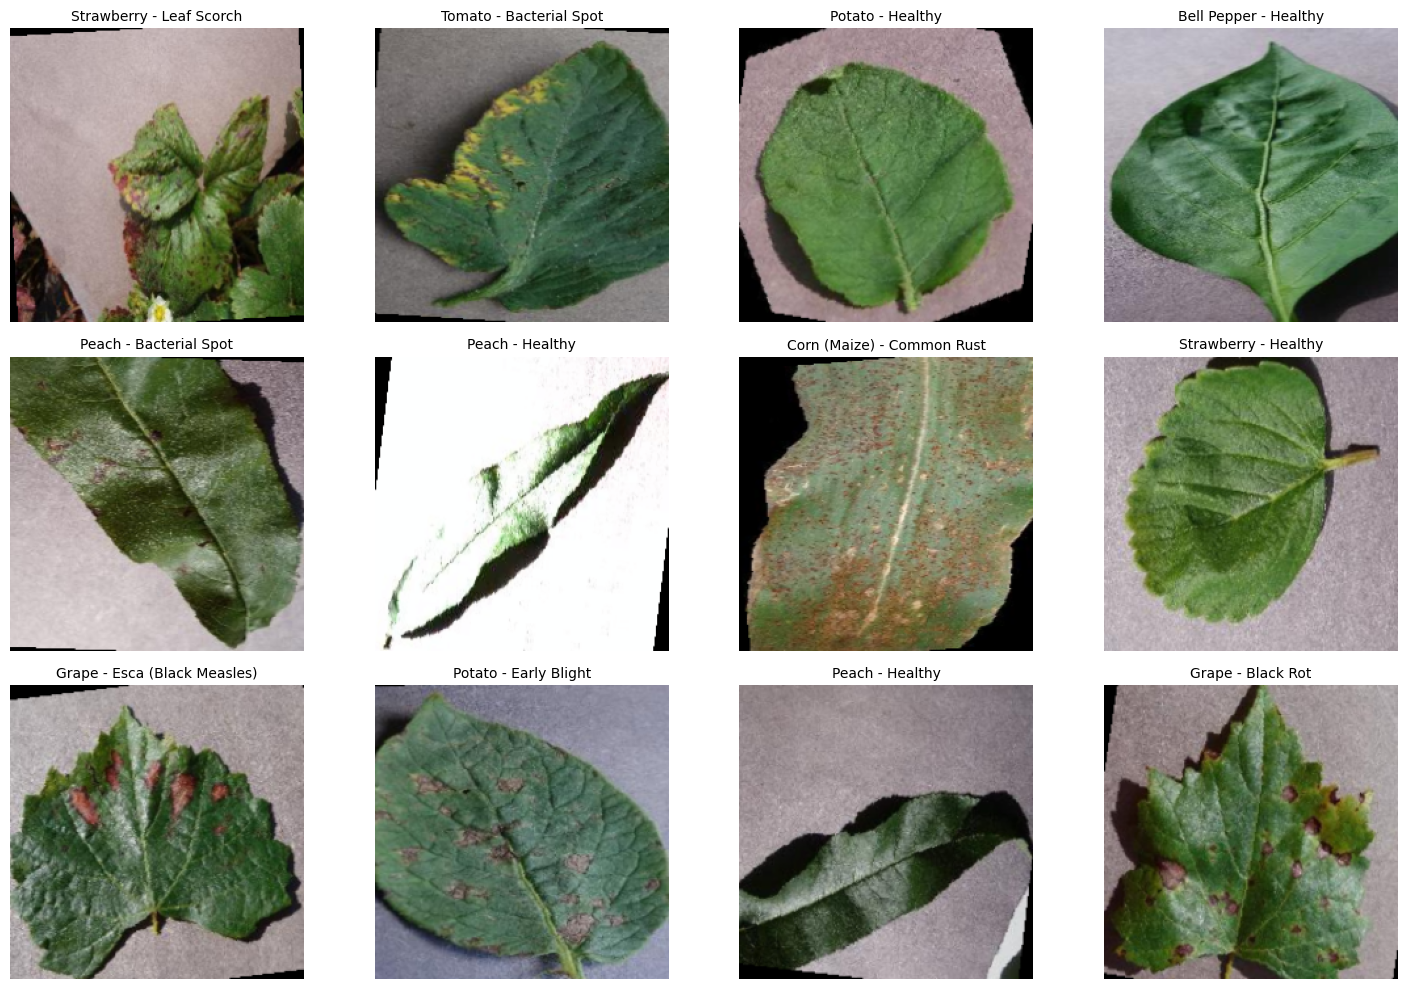

In [15]:
plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    
    # Get random image from train_dataset
    image, label = train_dataset[np.random.randint(0, len(train_dataset))]
    
    # Denormalize and convert to numpy
    image = image.numpy().transpose(1, 2, 0)
    image = (image * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)
    
    plt.imshow(image)
    plt.title(classes[label], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

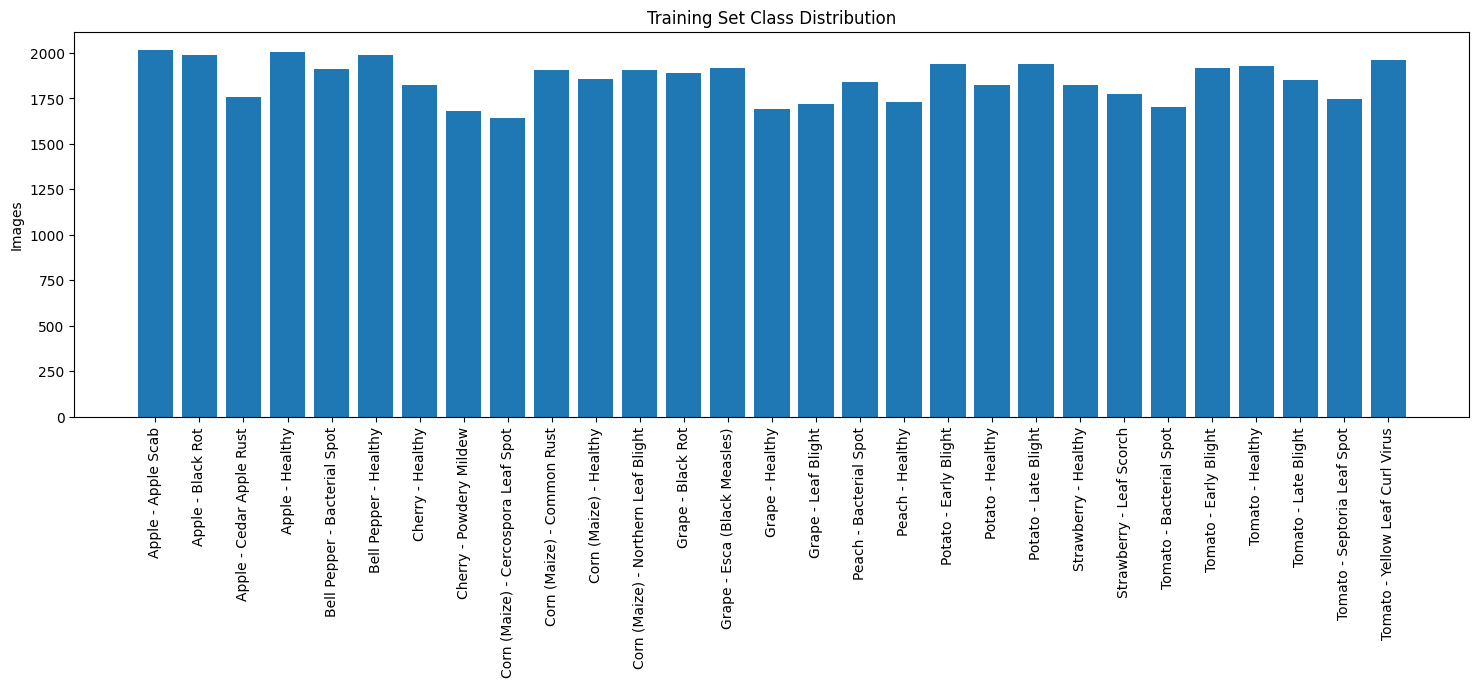

In [16]:
from collections import Counter

counter = Counter()

for _, labels in train_ds:
    counter.update(np.argmax(labels.numpy(), axis=1))

counts = [counter[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(18,5))
plt.bar(class_names, counts)
plt.xticks(rotation=90)
plt.ylabel("Images")
plt.title("Training Set Class Distribution")
plt.show()

In [16]:
model = timm.create_model(
    "convnextv2_tiny.fcmae_ft_in1k",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

In [17]:
for param in model.parameters():
    param.requires_grad = False

# Enable gradients only for the classifier
for param in model.head.parameters():
    param.requires_grad = True

In [18]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

Trainable Parameters : 23,837
Total Parameters     : 27,888,797


In [19]:
criterion = nn.CrossEntropyLoss()

In [20]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

In [21]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.2,
    patience=2
)

In [22]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    progress = tqdm(loader)

    for images, labels in progress:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

        progress.set_description(
            f"Loss:{running_loss/(total/loader.batch_size):.4f}"
        )

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [23]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predictions = outputs.argmax(1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [24]:
EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_accuracy = 0

In [25]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "best_convnextv2.pth"
        )

        print("Model Saved")


Epoch 1/10


/Users/pravin/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/1678 [00:02<?, ?it/s]

Train Loss : 0.3515
Train Acc  : 0.9226
Val Loss   : 0.1224
Val Acc    : 0.9654
Model Saved

Epoch 2/10


  0%|          | 0/1678 [00:02<?, ?it/s]

...

Train Loss : 0.0277
Train Acc  : 0.9905
Val Loss   : 0.0460
Val Acc    : 0.9842
Model Saved

Epoch 9/10


  0%|          | 0/1678 [00:02<?, ?it/s]

Train Loss : 0.0247
Train Acc  : 0.9916
Val Loss   : 0.0446
Val Acc    : 0.9848
Model Saved

Epoch 10/10


  0%|          | 0/1678 [00:02<?, ?it/s]

Train Loss : 0.0242
Train Acc  : 0.9922
Val Loss   : 0.0419
Val Acc    : 0.9857
Model Saved


In [26]:
model.load_state_dict(torch.load("best_convnextv2.pth"))

model.to(device)

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), 

In [27]:
print(model)

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), 

In [28]:
for param in model.parameters():
    param.requires_grad = False
    
for param in model.stages[-1].parameters():
    param.requires_grad = True

In [29]:
for param in model.head.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable Parameters: {trainable:,}")

Trainable Parameters: 15,510,557


In [30]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

In [31]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)

In [ ]:
FINE_TUNE_EPOCHS = 15

best_accuracy = 0

for epoch in range(FINE_TUNE_EPOCHS):

    print(f"\nFine-Tuning Epoch {epoch+1}/{FINE_TUNE_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "convnextv2_crop_best.pth"
        )

        print("Best model updated")